In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [26]:
df=pd.read_csv(r"C:\Users\CHAIT\OneDrive\Desktop\TE\Machine Learning\Dataset\ridge_lasso_house_price_dataset.csv")
df.head()


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,location_score,nearby_schools,distance_city_km,house_id_score,random_feature,price
0,5,2.5,2323,11985,1.5,0,4,3,2051,272,2009,0,6.48,10,21.39,61.19,1.4572,904772
1,2,1.0,1910,3284,1.0,1,1,3,1453,457,1968,0,5.56,2,5.58,52.34,0.5206,764838
2,4,3.5,2421,7828,3.0,0,2,5,2026,395,2010,0,2.43,8,24.73,61.99,0.2911,585957
3,5,3.0,2990,11364,2.0,0,3,1,2619,371,2013,0,1.57,4,5.45,67.88,-1.3197,675653
4,3,2.0,1848,3084,1.0,0,1,5,1430,418,1996,2001,2.06,5,7.32,44.22,0.5673,547169


In [27]:
sc=StandardScaler()
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [28]:
scaled_data=pd.DataFrame(sc.fit_transform(x),columns=x.columns)

In [29]:
x=scaled_data
from sklearn.model_selection import train_test_split

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


# Linear Regression

In [31]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge

In [32]:
lr=LinearRegression()

In [33]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
lr.score(x_train,y_train)

0.9162391009915379

In [35]:
lr.score(x_test,y_test)

0.8960112943346541

In [65]:
print('Mean squred error: ',mean_squared_error(y_test,lr.predict(x_test)))
print('Mean absolute error: ',mean_absolute_error(y_test,lr.predict(x_test)))

Mean squred error:  3666712809.7076387
Mean absolute error:  48671.87247991209


In [36]:
lr.coef_

array([  7826.29494874,  16847.10087388,  47013.1998534 ,   1158.60421904,
        -1797.08313364,  61383.00730641,  35318.10411847,  20324.25430407,
        47753.73238211,  22715.80880906,  25252.00876137,  23648.15329846,
        73359.09234365,   8069.89403881, -28312.24520904,   1090.75702876,
        -2658.06884308])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'bedrooms'),
  Text(1, 0, 'bathrooms'),
  Text(2, 0, 'sqft_living'),
  Text(3, 0, 'sqft_lot'),
  Text(4, 0, 'floors'),
  Text(5, 0, 'waterfront'),
  Text(6, 0, 'view'),
  Text(7, 0, 'condition'),
  Text(8, 0, 'sqft_above'),
  Text(9, 0, 'sqft_basement'),
  Text(10, 0, 'yr_built'),
  Text(11, 0, 'yr_renovated'),
  Text(12, 0, 'location_score'),
  Text(13, 0, 'nearby_schools'),
  Text(14, 0, 'distance_city_km'),
  Text(15, 0, 'house_id_score'),
  Text(16, 0, 'random_feature')])

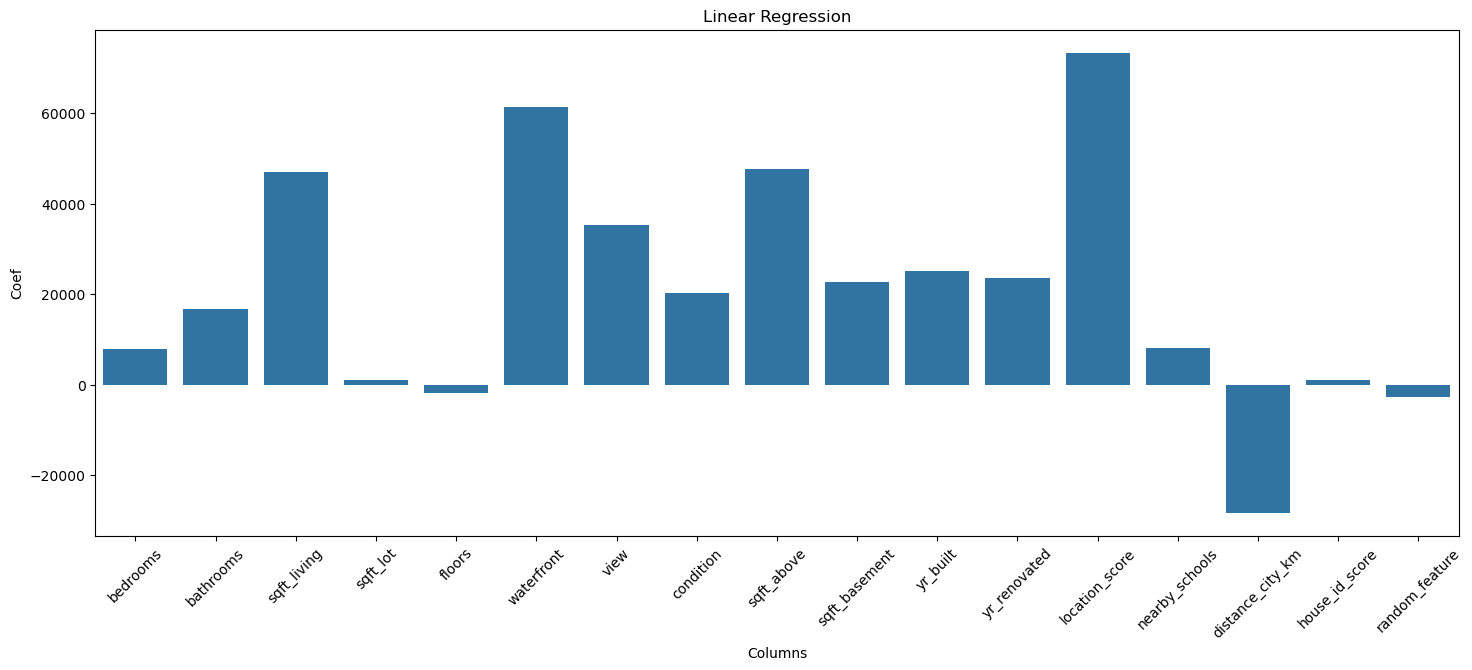

In [46]:
plt.figure(figsize=(15,6))
sns.barplot(x=x.columns,y=lr.coef_)
plt.title('Linear Regression')
plt.xlabel('Columns')
plt.ylabel('Coef')
plt.tight_layout()
plt.xticks(rotation=45)

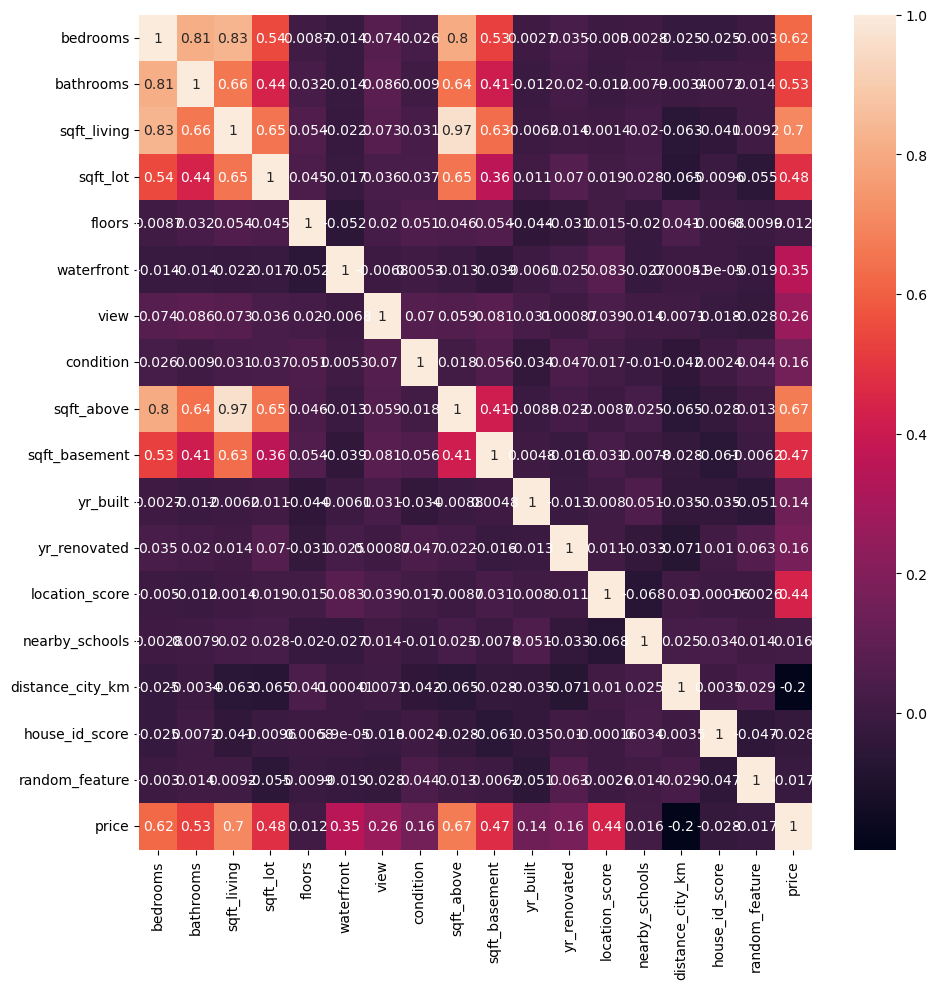

In [49]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.tight_layout()
plt.show()

# Lasso

In [63]:
la=Lasso(alpha=10)
la.fit(x_train,y_train)
la.score(x_test,y_test)*100


89.6023086148858

In [64]:
print('Mean squred error: ',mean_squared_error(y_test,la.predict(x_test)))
print('Mean absolute error: ',mean_absolute_error(y_test,la.predict(x_test)))

Mean squred error:  3666297022.2823143
Mean absolute error:  48669.5695687612


# Ridge

In [61]:
ri=Ridge(alpha=10)
ri.fit(x_train,y_train)
ri.score(x_test,y_test)*100

89.5613052435413

In [62]:
print('Mean squred error: ',mean_squared_error(y_test,ri.predict(x_test)))
print('Mean absolute error: ',mean_absolute_error(y_test,ri.predict(x_test)))

Mean squred error:  3680755091.164715
Mean absolute error:  48776.98557606604


In [76]:
df2=pd.DataFrame({"column name":x.columns,'Linear Regression':lr.coef_,'lasso':la.coef_,'Ridge':ri.coef_})
df2.head(18)

,column name,Linear Regression,lasso,Ridge
0,bedrooms,7826.294949,7824.807366,9719.741203
1,bathrooms,16847.100874,16842.113897,16317.989027
2,sqft_living,47013.199853,103109.618155,45856.656243
3,sqft_lot,1158.604219,1155.472117,2071.205214
4,floors,-1797.083134,-1787.054047,-1748.471058
5,waterfront,61383.007306,61374.389078,60521.604439
6,view,35318.104118,35310.743501,34856.823860
7,condition,20324.254304,20314.236092,20023.579689
8,sqft_above,47753.732382,0.000000,46429.322790
9,sqft_basement,22715.808809,7000.954916,22611.923386


In [75]:
df.shape

(800, 18)